In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import nest_asyncio

# Apply nest_asyncio to allow multiple event loops in Jupyter/Colab
nest_asyncio.apply()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [4]:
data = pd.read_csv("final_dataset_parkinson.csv")
data.head()

,subject_id,age,height,weight,gender,condition,Dribbling of saliva during the daytime,Loss or change in your ability to taste or smell,Difficulty swallowing food or drink or problems with choking,Vomiting or feelings of sickness (nausea),...,Swing_Time,Stance_Time,Step_Asymmetry,Bradykinesia_Index,Arm_Swing_Asymmetry,Amplitude_of_Tremor,Resting_Heart_Rate,Stress_Level,Sleep_Fragmentation,Sleep_Duration
0,1,56,173,78,male,Healthy,False,False,False,False,...,0.381607,1.404303,0.484870,0.221284,0.695639,0.500516,53,4.034032,0.511682,5.157095
1,1,56,173,78,male,Healthy,False,False,False,False,...,0.380208,0.706746,0.197221,0.788111,0.845934,0.173884,81,8.303848,0.270231,7.526873
2,1,56,173,78,male,Healthy,False,False,False,False,...,0.438578,1.148410,0.121830,0.317671,0.174807,4.317072,59,6.505994,0.605695,7.995964
3,1,56,173,78,male,Healthy,False,False,False,False,...,0.312286,0.977111,0.416981,0.784919,0.907044,1.051604,66,9.794921,0.427537,6.224073
4,1,56,173,78,male,Healthy,False,False,False,False,...,0.489998,0.742561,0.490448,0.730449,0.434793,4.246496,76,6.755177,0.906475,8.759062


In [5]:
del data['subject_id']

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10318 entries, 0 to 10317
Data columns (total 69 columns):
 #   Column                                                                                             Non-Null Count  Dtype  
---  ------                                                                                             --------------  -----  
 0   age                                                                                                10318 non-null  int64  
 1   height                                                                                             10318 non-null  int64  
 2   weight                                                                                             10318 non-null  int64  
 3   gender                                                                                             10318 non-null  object 
 4   condition                                                                                          10318 non-null  obj

In [7]:
data.shape

(10318, 69)

In [8]:
# Display all column names with their data types
print(data.dtypes)


age                      int64
height                   int64
weight                   int64
gender                  object
condition               object
                        ...   
Amplitude_of_Tremor    float64
Resting_Heart_Rate       int64
Stress_Level           float64
Sleep_Fragmentation    float64
Sleep_Duration         float64
Length: 69, dtype: object


In [9]:
data.columns

Index(['age', 'height', 'weight', 'gender', 'condition',
       'Dribbling of saliva during the daytime',
       'Loss or change in your ability to taste or smell',
       'Difficulty swallowing food or drink or problems with choking',
       'Vomiting or feelings of sickness (nausea)',
       'Constipation (less than 3 bowel movements a week) or having to strain to pass a stool (faeces)',
       'Bowel (fecal) incontinence',
       'Feeling that your bowel emptying is incomplete after having been to the toilet',
       'A sense of urgency to pass urine makes you rush to the toilet',
       'Getting up regularly at night to pass urine',
       'Unexplained pains (not due to known conditions such as arthritis)',
       'Unexplained change in weight (not due to change in diet)',
       'Problems remembering things that have happened recently or forgetting to do things',
       'Loss of interest in what is happening around you or doing things',
       'Seeing or hearing things that you kn

In [10]:
data = data.dropna()

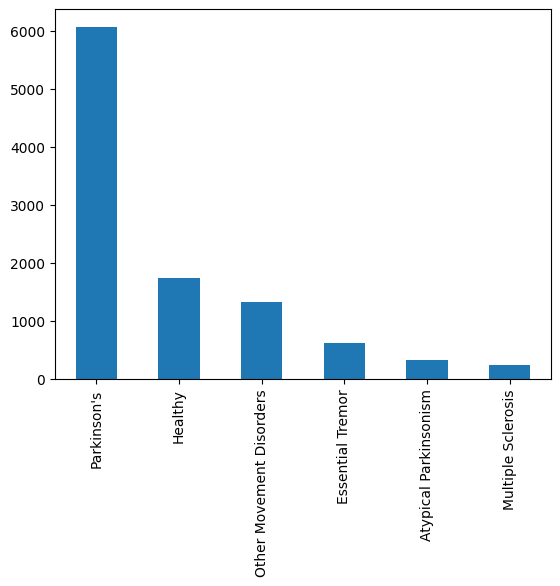

In [11]:
data['condition'].value_counts().plot(kind='bar');

In [12]:
# Convert boolean columns to integer (True → 1, False → 0)
data.loc[:, data.select_dtypes('bool').columns] = data.select_dtypes('bool').astype(int)

# Convert float columns to integer
data.loc[:, data.select_dtypes('float64').columns] = data.select_dtypes('float64').astype(int)

# Convert categorical (object) columns to integer (Label Encoding)
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in data.select_dtypes('object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])  # Convert categories to numeric values
    label_encoders[col] = le  # Store encoder for future use if needed

# Convert remaining int64 columns to int (this step is optional)
data.loc[:, data.select_dtypes('int64').columns] = data.select_dtypes('int64').astype(int)

# Display updated data types
print(data.dtypes)


age                    int32
height                 int32
weight                 int32
gender                 int32
condition              int32
                       ...  
Amplitude_of_Tremor    int32
Resting_Heart_Rate     int32
Stress_Level           int32
Sleep_Fragmentation    int32
Sleep_Duration         int32
Length: 69, dtype: object


In [13]:
from sklearn.metrics import accuracy_score, classification_report

In [14]:
X = data.drop(["condition"],axis =1)
y = data["condition"]

In [15]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif

selector = SelectPercentile(mutual_info_classif, percentile=20)
X_reduced = selector.fit_transform(X, y)
X_reduced.shape

(10318, 14)

In [ ]:
# Check feature importance scores
import pandas as pd

selector = SelectPercentile(mutual_info_classif, percentile=20)  # Increase to 10%
X_reduced = selector.fit_transform(X, y)

# Show selected feature names and scores
selected_features = X.columns[selector.get_support()]
feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print(f"Selected Features: {selected_features}")
print(feature_scores)


In [ ]:
cols = selector.get_support(indices=True)
selected_columns = X.iloc[:,cols].columns.tolist()
selected_columns

['age',
 'height',
 'weight',
 'Dribbling of saliva during the daytime',
 'Loss or change in your ability to taste or smell',
 'Constipation (less than 3 bowel movements a week) or having to strain to pass a stool (faeces)',
 'Feeling that your bowel emptying is incomplete after having been to the toilet',
 'A sense of urgency to pass urine makes you rush to the toilet',
 'Getting up regularly at night to pass urine',
 'Loss of interest in what is happening around you or doing things',
 'Finding it difficult to have sex when you try',
 'Feeling light headed, dizzy or weak standing from sitting or lying',
 'Intense, vivid dreams or frightening dreams',
 'Talking or moving about in your sleep as if you are acting out a dream']

In [ ]:
df = data[['age',
 'height',
 'weight',
 'Dribbling of saliva during the daytime',
 'Loss or change in your ability to taste or smell',
 'Constipation (less than 3 bowel movements a week) or having to strain to pass a stool (faeces)',
 'Feeling that your bowel emptying is incomplete after having been to the toilet',
 'A sense of urgency to pass urine makes you rush to the toilet',
 'Getting up regularly at night to pass urine',
 'Loss of interest in what is happening around you or doing things',
 'Finding it difficult to have sex when you try',
 'Feeling light headed, dizzy or weak standing from sitting or lying',
 'Intense, vivid dreams or frightening dreams',
 'Talking or moving about in your sleep as if you are acting out a dream','condition']]
df.to_csv('newdata.csv')

In [6]:
df=pd.read_csv("newdata.csv")

In [7]:
df.head()

,age,height,weight,Dribbling of saliva during the daytime,Loss or change in your ability to taste or smell,Constipation (less than 3 bowel movements a week) or having to strain to pass a stool (faeces),Feeling that your bowel emptying is incomplete after having been to the toilet,A sense of urgency to pass urine makes you rush to the toilet,Getting up regularly at night to pass urine,Loss of interest in what is happening around you or doing things,Finding it difficult to have sex when you try,"Feeling light headed, dizzy or weak standing from sitting or lying","Intense, vivid dreams or frightening dreams",Talking or moving about in your sleep as if you are acting out a dream,condition
0,56,173,78,0,0,0,0,0,0,0,0,0,0,0,2
1,56,173,78,0,0,0,0,0,0,0,0,0,0,0,2
2,56,173,78,0,0,0,0,0,0,0,0,0,0,0,2
3,56,173,78,0,0,0,0,0,0,0,0,0,0,0,2
4,56,173,78,0,0,0,0,0,0,0,0,0,0,0,2


In [8]:
df.columns

Index(['age', 'height', 'weight', 'Dribbling of saliva during the daytime',
       'Loss or change in your ability to taste or smell',
       'Constipation (less than 3 bowel movements a week) or having to strain to pass a stool (faeces)',
       'Feeling that your bowel emptying is incomplete after having been to the toilet',
       'A sense of urgency to pass urine makes you rush to the toilet',
       'Getting up regularly at night to pass urine',
       'Loss of interest in what is happening around you or doing things',
       'Finding it difficult to have sex when you try',
       'Feeling light headed, dizzy or weak standing from sitting or lying',
       'Intense, vivid dreams or frightening dreams',
       'Talking or moving about in your sleep as if you are acting out a dream',
       'condition'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10318 entries, 0 to 10317
Data columns (total 15 columns):
 #   Column                                                                                          Non-Null Count  Dtype
---  ------                                                                                          --------------  -----
 0   age                                                                                             10318 non-null  int64
 1   height                                                                                          10318 non-null  int64
 2   weight                                                                                          10318 non-null  int64
 3   Dribbling of saliva during the daytime                                                          10318 non-null  int64
 4   Loss or change in your ability to taste or smell                                                10318 non-null  int64
 5   Constipation (less than 3

In [10]:
X = df.drop(columns=['condition']).values  # Replace 'target' with the actual target column name
y = df['condition'].values

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
print(X_scaled.shape, y.shape)

(10318, 14) (10318,)


In [13]:
# Convert the feature data to float32 and label data to int64
X_scaled = X_scaled.astype(np.float32)
y = y.astype(np.int64)

# Check the data types to confirm
print(f"Features type: {X_scaled.dtype}, Labels type: {y.dtype}")


Features type: float32, Labels type: int64


In [19]:
import tensorflow as tf
# Create a function to generate federated data
def create_federated_data(X, y, num_clients):
    client_data = []
    client_data_size = len(X) // num_clients
    for i in range(num_clients):
        start = i * client_data_size
        end = (i + 1) * client_data_size
        client_data.append(tf.data.Dataset.from_tensor_slices((X[start:end], y[start:end])).batch(32))
    return client_data

AttributeError: module 'numpy' has no attribute 'typeDict'

In [17]:
# Create federated data (split data into 10 clients)
num_clients = 10
federated_train_data = create_federated_data(X_scaled, y, num_clients)


NameError: name 'tf' is not defined

In [ ]:
# Check the first client’s data
for example in federated_train_data[0].take(1):
    print(example)

(<tf.Tensor: shape=(32, 14), dtype=float32, numpy=
array([[-0.77108663, -0.10827351, -0.2179    , -0.6324555 , -0.7229988 ,
        -0.7367246 , -0.5732468 , -1.1153561 , -1.1801937 , -0.6060915 ,
        -0.5732468 , -0.70936954, -0.57981235, -0.69582844],
       [-0.77108663, -0.10827351, -0.2179    , -0.6324555 , -0.7229988 ,
        -0.7367246 , -0.5732468 , -1.1153561 , -1.1801937 , -0.6060915 ,
        -0.5732468 , -0.70936954, -0.57981235, -0.69582844],
       [-0.77108663, -0.10827351, -0.2179    , -0.6324555 , -0.7229988 ,
        -0.7367246 , -0.5732468 , -1.1153561 , -1.1801937 , -0.6060915 ,
        -0.5732468 , -0.70936954, -0.57981235, -0.69582844],
       [-0.77108663, -0.10827351, -0.2179    , -0.6324555 , -0.7229988 ,
        -0.7367246 , -0.5732468 , -1.1153561 , -1.1801937 , -0.6060915 ,
        -0.5732468 , -0.70936954, -0.57981235, -0.69582844],
       [-0.77108663, -0.10827351, -0.2179    , -0.6324555 , -0.7229988 ,
        -0.7367246 , -0.5732468 , -1.1153561 , -

# DNN with FL

In [ ]:
pip uninstall tensorflow tensorflow-estimator tensorflow-federated tensorflow-privacy -y


Note: you may need to restart the kernel to use updated packages.


In [ ]:
!pip install --no-deps tensorflow-federated

  Using cached tensorflow_federated-0.33.0-py2.py3-none-any.whl.metadata (3.4 kB)
   ---------------------------------------- 0.0/885.7 kB ? eta -:--:--
   ----------------------- ---------------- 524.3/885.7 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 885.7/885.7 kB 2.7 MB/s eta 0:00:00


In [ ]:
!pip install jax==0.4.10
!pip install cachetools==4.2.1
!pip install dp_accounting
!pip install tensorflow_privacy
!pip install tensorflow_compression
!pip install tensorflow_model_optimization
!pip install pyfarmhash
!pip install google-vizier

     ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
     ---------------- ----------------------- 0.5/1.3 MB 2.8 MB/s eta 0:00:01
     ---------------------------------------- 1.3/1.3 MB 4.1 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for jax: filename=jax-0.4.10-py3-none-any.whl size=1480614 sha256=642d2668407eb76de87d86bf34646f67c30e311f3cb362712937adf3df92ac25
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\6a\8c\35\209bfba5979c08e883a5cfcb9f3ddf907f9dd1c37ee83c1f8d
Successfully built jax
  Attempting uninstall: jax
    Found existing installation: jax 0.4.13
    Uninstalling jax-0.4.13:
      Successfully uninstalled jax-0.4.13


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-federated 0.33.0 requires farmhashpy~=0.4.0, which is not installed.
tensorflow-federated 0.33.0 requires jaxlib~=0.3.10, which is not installed.
tensorflow-federated 0.33.0 requires portpicker~=1.5.2, which is not installed.
tensorflow-federated 0.33.0 requires semantic-version~=2.6.0, which is not installed.
tensorflow-federated 0.33.0 requires tensorflow-privacy~=0.8.1, which is not installed.
tensorflow-federated 0.33.0 requires absl-py~=1.0.0, but you have absl-py 2.1.0 which is incompatible.
tensorflow-federated 0.33.0 requires attrs~=21.4.0, but you have attrs 23.2.0 which is incompatible.
tensorflow-federated 0.33.0 requires grpcio~=1.46.3, but you have grpcio 1.70.0 which is incompatible.
tensorflow-federated 0.33.0 requires jax~=0.3.13, but you have jax 0.4.10 which is incompatible.
tensorflow

  Attempting uninstall: cachetools
    Found existing installation: cachetools 3.1.1
    Uninstalling cachetools-3.1.1:
      Successfully uninstalled cachetools-3.1.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-federated 0.33.0 requires farmhashpy~=0.4.0, which is not installed.
tensorflow-federated 0.33.0 requires jaxlib~=0.3.10, which is not installed.
tensorflow-federated 0.33.0 requires portpicker~=1.5.2, which is not installed.
tensorflow-federated 0.33.0 requires semantic-version~=2.6.0, which is not installed.
tensorflow-federated 0.33.0 requires tensorflow-privacy~=0.8.1, which is not installed.
tensorflow-federated 0.33.0 requires absl-py~=1.0.0, but you have absl-py 2.1.0 which is incompatible.
tensorflow-federated 0.33.0 requires attrs~=21.4.0, but you have attrs 23.2.0 which is incompatible.
tensorflow-federated 0.33.0 requires cachetools~=3.1.1, but you have cachetools 4.2.1 which is incompatible.
tensorflow-federated 0.33.0 requires grpcio~=1.46.3, but you have grpcio 1.70.0 which is incompatible

  Attempting uninstall: absl-py
    Found existing installation: absl-py 2.1.0
    Uninstalling absl-py-2.1.0:
      Successfully uninstalled absl-py-2.1.0


...


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
INFO: pip is looking at multiple versions of tf-models-official to determine which version is compatible with other requirements. This could take a while.
  Using cached kaggle-1.6.17.tar.gz (82 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
INFO: pip is still looking at multiple versions of tf-models-official to determine which version is compatible with other requirements. This could take a while.
  Using cached attrs-21.4.0-py2.py3-none-any.whl.metadata (9.8 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.0 MB 4.8 MB/s eta 0:00:03
   ------ ---------------------------------

ERROR: Could not find a version that satisfies the requirement tensorflow_compression (from versions: none)
ERROR: No matching distribution found for tensorflow_compression


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pyfarmhash: filename=pyfarmhash-0.4.0-cp38-cp38-win_amd64.whl size=14399 sha256=de2b5396dd1c9dd6ef97fd7ffccfb5960b14aedf82c979cd76b56a90d1ce27a4
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\cf\32\e0\4f7df40f87a6d5329cf34835dfc3d0af63d725840b5aa2f4f8
Successfully built pyfarmhash


  Using cached typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
   ---------------------------------------- 0.0/801.4 kB ? eta -:--:--
   ---------------------------------------- 801.4/801.4 kB 5.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------- -------------------- 1.0/2.1 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------  2.1/2.1 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 4.4 MB/s eta 0:00:00
Using cached typing_extensions-4.12.2-py3-none-any.whl (37 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.5.0
    Uninstalling typing_extensions-4.5.0:
      Successfully uninstalled typing_extensions-4.5.0
  Attempting uninstall: attrs
    Found existing installation: attrs 21.4.0
    Uninstalling attrs-21.4.0:
      Successfully uninstalled attrs-21.4.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-federated 0.33.0 requires farmhashpy~=0.4.0, which is not installed.
tensorflow-federated 0.33.0 requires jaxlib~=0.3.10, which is not installed.
tensorflow-federated 0.33.0 requires semantic-version~=2.6.0, which is not installed.
dp-accounting 0.4.2 requires attrs~=21.4, but you have attrs 25.1.0 which is incompatible.
tensorflow-federated 0.33.0 requires absl-py~=1.0.0, but you have absl-py 1.4.0 which is incompatible.
tensorflow-federated 0.33.0 requires attrs~=21.4.0, but you have attrs 25.1.0 which is incompatible.
tensorflow-federated 0.33.0 requires cachetools~=3.1.1, but you have cachetools 4.2.1 which is incompatible.
tensorflow-federated 0.33.0 requires grpcio~=1.46.3, but you have grpcio 1.70.0 which is incompatible.
tensorflow-federated 0.33.0 requires jax~=0.3.13, but you have jax 0.4.10 w

In [ ]:
import tensorflow as tf
import tensorflow_federated as tff

ImportError: cannot import name 'Event' from 'tensorflow.python' (unknown location)

In [ ]:
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(X_scaled.shape[1],)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')  # Parkinson's disease binary classification
    ])
    #model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def model_fn():
    keras_model = create_model()
    return tff.learning.from_keras_model(
        keras_model,
        input_spec=(tf.TensorSpec(shape=[None, X_scaled.shape[1]], dtype=tf.float32),
                    tf.TensorSpec(shape=[None], dtype=tf.int64)),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy()]
    )

In [ ]:
client_optimizer_fn = lambda: tf.keras.optimizers.Adam(learning_rate=0.001)
server_optimizer_fn = lambda: tf.keras.optimizers.Adam(learning_rate=1.0)

In [ ]:
# Build the federated averaging process
iterative_process = tff.learning.build_federated_averaging_process(
    model_fn,
    client_optimizer_fn=client_optimizer_fn,
    server_optimizer_fn=server_optimizer_fn
)

In [ ]:
# Initialize the federated learning process
state = iterative_process.initialize()

In [ ]:
num_rounds = 50
for round_num in range(1, num_rounds + 1):
    state, metrics = iterative_process.next(state, federated_train_data)
    print(f"Round {round_num}, Metrics: {metrics}")

Round 1, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 2, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026435)]))])
Round 3, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026428)]))])
Round 4, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026435)]))])
Round 5, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())

Round 39, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026435)]))])
Round 40, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026435)]))])
Round 41, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306817), ('loss', 3.8026435)]))])
Round 42, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306817), ('loss', 3.8026438)]))])
Round 43, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process'

In [ ]:
keras_model = create_model()
keras_model.save('tff_model.h5')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.20, random_state = 42)

In [ ]:
model = tf.keras.models.load_model('tff_model.h5')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

# Print the evaluation results
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

5/5 [==============================] - 0s 805us/step - loss: 0.6819 - accuracy: 0.5789
Test Loss: 0.6819158792495728
Test Accuracy: 0.5789473652839661


In [ ]:
val1 = 0.57

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Get model predictions on the test set
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary predictions

# Print classification report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

              precision    recall  f1-score   support

           0       0.31      0.55      0.40        38
           1       0.80      0.59      0.68       114

    accuracy                           0.58       152
   macro avg       0.55      0.57      0.54       152
weighted avg       0.68      0.58      0.61       152

Confusion Matrix:
[[21 17]
 [47 67]]


# CNN with FL

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# CNN Model Definition
def create_cnn_model(input_shape):
    model = models.Sequential()

    # Add Convolutional and Pooling layers
    model.add(layers.Reshape(target_shape=(input_shape[0], 1), input_shape=input_shape))  # Reshape for CNN input
    model.add(layers.Conv1D(64, 3, activation='relu'))  # 1D convolution layer
    model.add(layers.MaxPooling1D(2))  # Max pooling layer

    model.add(layers.Conv1D(128, 3, activation='relu'))  # Another convolutional layer
    model.add(layers.MaxPooling1D(2))

    # Flatten the output from convolutional layers
    model.add(layers.Flatten())

    # Fully connected layer
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))  # Dropout for regularization

    # Output layer for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))

    

    return model


In [ ]:
def model_fn():
    keras_model = create_cnn_model(input_shape=(13,))
    return tff.learning.from_keras_model(
        keras_model,
        input_spec=(tf.TensorSpec(shape=[None, X_scaled.shape[1]], dtype=tf.float32),
                    tf.TensorSpec(shape=[None], dtype=tf.int64)),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy()]
    )

In [ ]:
# Build the federated averaging process
iterative_process = tff.learning.build_federated_averaging_process(
    model_fn,
    client_optimizer_fn=client_optimizer_fn,
    server_optimizer_fn=server_optimizer_fn
)

In [ ]:
state = iterative_process.initialize()

In [ ]:
num_rounds = 50
for round_num in range(1, num_rounds + 1):
    state, metrics = iterative_process.next(state, federated_train_data)
    print(f"Round {round_num}, Metrics: {metrics}")

Round 1, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.6158144), ('loss', 0.68129605)]))])
Round 2, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 3, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 4, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 5, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ()

Round 39, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306817), ('loss', 3.8026433)]))])
Round 40, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 41, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306817), ('loss', 3.8026435)]))])
Round 42, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 43, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process'

In [ ]:
keras_model = create_cnn_model(input_shape=(13,))
keras_model.save('tff_cnn_model.h5')

In [ ]:
model = tf.keras.models.load_model('tff_cnn_model.h5')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

# Print the evaluation results
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

5/5 [==============================] - 0s 997us/step - loss: 0.6567 - accuracy: 0.7500
Test Loss: 0.6567240357398987
Test Accuracy: 0.75


In [ ]:
val2 = 0.75

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary predictions

# Print classification report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        38
           1       0.75      1.00      0.86       114

    accuracy                           0.75       152
   macro avg       0.38      0.50      0.43       152
weighted avg       0.56      0.75      0.64       152

Confusion Matrix:
[[  0  38]
 [  0 114]]


In [ ]:
from tensorflow.keras.models import Model, load_model
model = load_model('tff_cnn_model.h5')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
data = np.array([0,2.9311,0.015363,0.018959,1.4709,-252612.6532,-2114.5639,0.00018873,0.10106,0.00039114,0.018172,0.27556,0.083471
])

In [ ]:
dj = data.reshape(-1,13,1)
prediction_proba = model.predict(dj)

In [ ]:
predict=np.argmax(prediction_proba,axis=1)

In [ ]:
predict

array([0], dtype=int64)

# DL without FL

In [ ]:
df.columns

Index(['gender', 'mean_MFCC_2nd_coef', 'std_delta_delta_log_energy',
       'std_8th_delta_delta', 'tqwt_entropy_shannon_dec_35',
       'tqwt_entropy_log_dec_11', 'tqwt_entropy_log_dec_35',
       'tqwt_TKEO_mean_dec_12', 'tqwt_TKEO_mean_dec_16',
       'tqwt_TKEO_std_dec_12', 'tqwt_stdValue_dec_12', 'tqwt_stdValue_dec_15',
       'tqwt_maxValue_dec_12', 'class'],
      dtype='object')

In [ ]:
X = df.drop(["class"],axis =1)
y = df["class"]

# CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [ ]:
X_train=X_train.values
X_test=X_test.values

In [ ]:
X_train = X_train.reshape(-1, X_train.shape[1],1)
X_test = X_test.reshape(-1, X_test.shape[1],1)

Y_train=to_categorical(y_train)
Y_test=to_categorical(y_test)

In [ ]:
verbose, epoch, batch_size = 1, 100, 4
activationFunction='relu'

def CNN():
    
    cnnmodel = Sequential()
    cnnmodel.add(Conv1D(filters=128, kernel_size=2, activation='relu',input_shape=(X_train.shape[1],X_train.shape[2])))
    cnnmodel.add(MaxPooling1D(pool_size=2))
    cnnmodel.add(Dropout(rate=0.2))
    cnnmodel.add(Flatten())
    cnnmodel.add(Dense(2, activation='softmax'))
    cnnmodel.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])
    cnnmodel.summary()
    return cnnmodel

cnnmodel = CNN()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_3 (Conv1D)            (None, 12, 128)           384       
_________________________________________________________________
max_pooling1d_3 (MaxPooling1 (None, 6, 128)            0         
_________________________________________________________________
dropout_2 (Dropout)          (None, 6, 128)            0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 768)               0         
_________________________________________________________________
dense_9 (Dense)              (None, 2)                 1538      
Total params: 1,922
Trainable params: 1,922
Non-trainable params: 0
_________________________________________________________________


In [ ]:
modelhistory= cnnmodel.fit(X_train, Y_train, epochs=50, verbose=verbose, validation_split=0.2, batch_size = batch_size)

Epoch 1/50
  1/121 [..............................] - ETA: 0s - loss: 3320.2498 - accuracy: 0.5000WARNING:tensorflow:Callbacks method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0000s vs `on_train_batch_end` time: 0.0010s). Check your callbacks.


121/121 [==============================] - 0s 2ms/step - loss: 2768.0588 - accuracy: 0.6273 - val_loss: 632.9136 - val_accuracy: 0.7934
Epoch 2/50
121/121 [==============================] - 0s 849us/step - loss: 2275.5767 - accuracy: 0.6046 - val_loss: 39.1084 - val_accuracy: 0.7934
Epoch 3/50
121/121 [==============================] - 0s 849us/step - loss: 2033.7721 - accuracy: 0.6170 - val_loss: 403.2770 - val_accuracy: 0.7934
Epoch 4/50
121/121 [==============================] - 0s 857us/step - loss: 1458.0804 - accuracy: 0.6211 - val_loss: 649.1080 - val_accuracy: 0.7934
Epoch 5/50
121/121 [==============================] - 0s 849us/step - loss: 1137.2750 - accuracy: 0.6377 - val_loss: 498.4076 - val_accuracy: 0.7934
Epoch 6/50
121/121 [==============================] - 0s 841us/step - loss: 754.6341 - accuracy: 0.6398 - val_loss: 853.8241 - val_accuracy: 0.7934
Epoch 7/50
121/121 [==============================] - 0s 866us/step - loss: 623.2328 - accuracy: 0.6025 - val_loss: 315.3

In [ ]:
val3 = modelhistory.history['val_accuracy'][49]

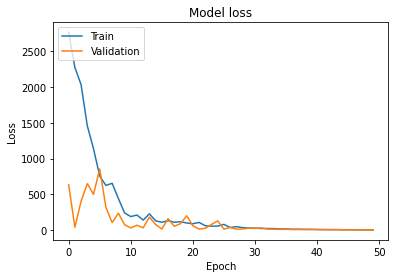

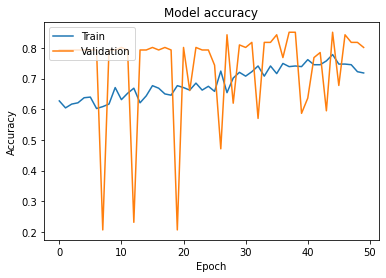

In [ ]:
# Plot training & validation loss values
plt.plot(modelhistory.history['loss'])
plt.plot(modelhistory.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss.png', format='png', dpi=1200)
plt.show()


# Plot training & validation accuracy values
plt.plot(modelhistory.history['accuracy'])
plt.plot(modelhistory.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('accuracy.png', format='png', dpi=1200)
plt.show()

# ML

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((604, 13), (604,), (152, 13), (152,))

# XGBoost

In [ ]:
from xgboost import XGBClassifier

# instantiate the model 
clf = XGBClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val4 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.61      0.82      0.70        28
           1       0.96      0.88      0.92       124

    accuracy                           0.87       152
   macro avg       0.78      0.85      0.81       152
weighted avg       0.89      0.87      0.88       152



# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# instantiate the model 
clf = RandomForestClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val5 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.61      0.85      0.71        27
           1       0.96      0.88      0.92       125

    accuracy                           0.88       152
   macro avg       0.79      0.87      0.81       152
weighted avg       0.90      0.88      0.88       152



# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val6 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.63      0.67      0.65        36
           1       0.89      0.88      0.89       116

    accuracy                           0.83       152
   macro avg       0.76      0.77      0.77       152
weighted avg       0.83      0.83      0.83       152



# Extension

In [ ]:
from sklearn.ensemble import VotingClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200
)

model = VotingClassifier(estimators= [('BoostDT', bdt),('RF', rf)], voting='soft')

model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [ ]:
print(classification_report(predictions, y_test))

              precision    recall  f1-score   support

           0       0.63      0.89      0.74        27
           1       0.97      0.89      0.93       125

    accuracy                           0.89       152
   macro avg       0.80      0.89      0.83       152
weighted avg       0.91      0.89      0.90       152



In [ ]:
val7 = accuracy_score(predictions, y_test)

# Comparison

In [ ]:
results=pd.DataFrame({'Model':['DNN-FL','CNN-FL','CNN','XGB','RF','DT','Extension'],
                    'Accuracy Score':[val1,val2,val3,val4,val5,val6,val7]})
result_df=results.sort_values(by='Accuracy Score', ascending=False)
result_df=result_df.set_index('Model')
result_df

,Accuracy Score
Model,
Extension,0.888158
RF,0.875000
XGB,0.868421
DT,0.828947
CNN,0.801653
CNN-FL,0.750000
DNN-FL,0.570000


# Modelling

In [ ]:
import joblib
#filename = 'model.sav'
joblib.dump(model, 'model.sav')

['model.sav']

# Graph

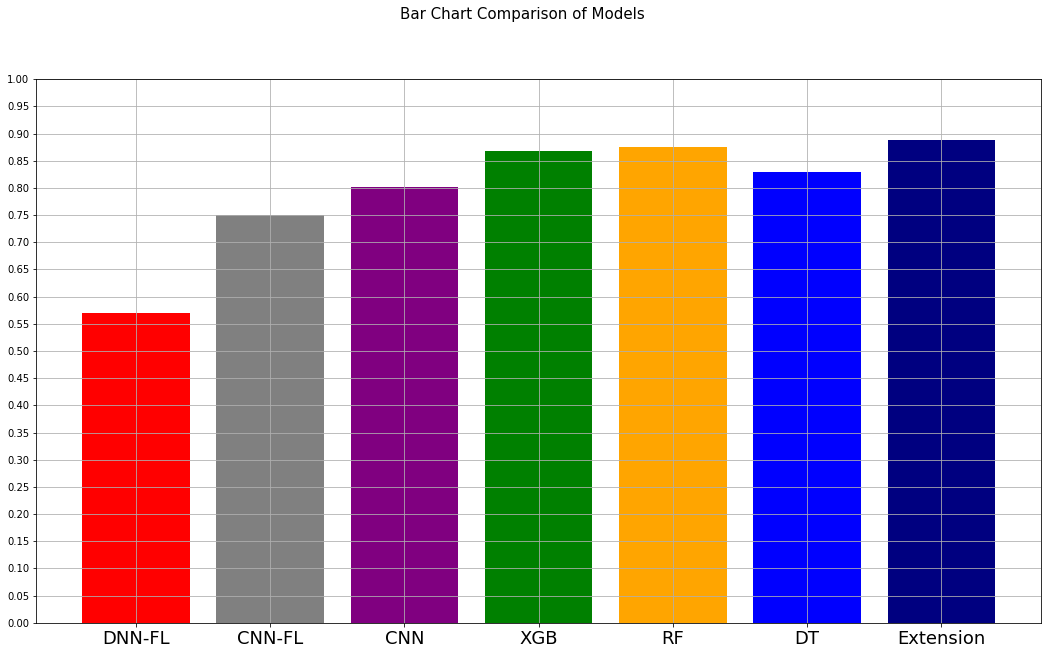

In [ ]:
algorithms=('DNN-FL','CNN-FL','CNN','XGB','RF','DT','Extension')
scores = (val1,val2,val3,val4,val5,val6,val7)
y_pos = np.arange(1,8)
colors = ("red","gray","purple","green","orange","blue","navy")
plt.figure(figsize=(18,10))
plt.bar(y_pos,scores,color=colors)
plt.xticks(y_pos,algorithms,fontsize=18)
plt.yticks(np.arange(0.00, 1.01, step=0.05))
plt.grid()
plt.suptitle("Bar Chart Comparison of Models",fontsize=15)
plt.show()